# Tutorial 3: Running Quantization-Aware Training (QAT) on Bert

In this tutorial, we'll build on top of Tutorial 2 by taking the Bert model fine tuned for sequence classification and running Mase's quantization pass. First, we'll run simple Post-Training Quantization (PTQ) and see how much accuracy drops. Then, we'll run some further training iterations of the quantized model (i.e. QAT) and see whether the accuracy of the trained quantized model approaches the accuracy of the original (full-precision) model.

In [9]:
checkpoint = "prajjwal1/bert-tiny"
tokenizer_checkpoint = "bert-base-uncased"
dataset_name = "imdb"

In [10]:
import torch
import torch.nn as nn

class BatchNorm2d(nn.Module):
    def __init__(self, num_features, eps=1e-05, momentum=0.1):
        super(BatchNorm2d, self).__init__()
        """
        An implementation of a Batch Normalization over a mini-batch of 2D inputs.

        The mean and standard-deviation are calculated per-dimension over the
        mini-batches and gamma and beta are learnable parameter vectors of
        size num_features.

        Parameters:
        - num_features: C from an expected input of size (N, C, H, W).
        - eps: a value added to the denominator for numerical stability. Default: 1e-5
        - momentum: the value used for the running_mean and running_var
        computation. Default: 0.1 . (i.e. 1-momentum for running mean)
        - gamma: the learnable weights of shape (num_features).
        - beta: the learnable bias of the module of shape (num_features).
        """
        # TODO: Define the parameters used in the forward pass                 #
        # *****START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****        #
        self.num_features = num_features
        self.eps = eps
        self.momentum = momentum
        
        # self.register_parameter is not used as it was mentioned on piazza
        # that this will be overridden
        self.gamma = nn.Parameter(torch.ones(num_features))  # Scale
        self.beta = nn.Parameter(torch.zeros(num_features))  # Shift
        
        # Non-trainable buffers for (train) running statistics
        self.register_buffer("running_mean", torch.zeros(num_features))
        self.register_buffer("running_var", torch.ones(num_features))
        # *****END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****

    def forward(self, x):
        """
        During training this layer keeps running estimates of its computed mean and
        variance, which are then used for normalization during evaluation.
        Input:
        - x: Input data of shape (N, C, H, W)
        Output:
        - out: Output data of shape (N, C, H, W) (same shape as input)
        """
        # TODO: Implement the forward pass                                     #
        #       (be aware of the difference for training and testing)          #
        # *****START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****
        N, C, H, W = x.shape

        if self.training:
            # Compute batch mean and variance
            batch_mean = x.mean(dim=(0, 2, 3))  # Mean over N, H, W for each channel
            batch_var = x.var(dim=(0, 2, 3), unbiased=False)  # Variance over N, H, W for each channel

            # Normalize input
            x_normalized = (x - batch_mean[None, :, None, None]) / torch.sqrt(batch_var[None, :, None, None] + self.eps)

            # Update running estimates
            self.running_mean = self.momentum * batch_mean + (1 - self.momentum) * self.running_mean
            self.running_var = self.momentum * batch_var + (1 - self.momentum) * self.running_var
        else:
            # Use running estimates for normalization
            x_normalized = (x - self.running_mean[None, :, None, None]) / torch.sqrt(self.gamma[None, :, None, None] + self.eps)

        # Apply scale (gamma) and shift (beta)
        out = self.gamma[None, :, None, None] * x_normalized + self.beta[None, :, None, None]
        # *****END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****
        return x

## Importing the model

If you are starting from scratch, you can create a MaseGraph for Bert by running the following cell.

In [11]:
from transformers import AutoModelForSequenceClassification

from chop import MaseGraph
import chop.passes as passes

model = AutoModelForSequenceClassification.from_pretrained(checkpoint)
model.config.problem_type = "single_label_classification"

mg = MaseGraph(
    model,
    hf_input_names=[
        "input_ids",
        "attention_mask",
        "labels",
    ],
)

mg, _ = passes.init_metadata_analysis_pass(mg)
mg, _ = passes.add_common_metadata_analysis_pass(mg)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at prajjwal1/bert-tiny and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
`past_key_values` were not specified as input names, but model.config.use_cache = True. Setting model.config.use_cache = False.
INFO     Getting dummy input for prajjwal1/bert-tiny.


tensor([[ 101, 9932, 2089, 2202, 2058, 1996, 2088, 2028, 2154,  102],
        [ 101, 2023, 2003, 2339, 2017, 2323, 4553, 4748, 4877,  102]])
tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
tensor([[ 101, 9932, 2089, 2202, 2058, 1996, 2088, 2028, 2154,  102],
        [ 101, 2023, 2003, 2339, 2017, 2323, 4553, 4748, 4877,  102]])
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])
tensor([[[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]],


        [[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]]])
tensor([[[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       

If you have previously ran the tutorial on LoRA Finetuning, run the following cell to import the fine tuned checkpoint.

In [12]:
from pathlib import Path
from chop import MaseGraph

mg = MaseGraph.from_checkpoint(f"{Path.home()}/tutorial_2_lora")

WARNING  Node finfo not found in loaded metadata.
WARNING  Node getattr_2 not found in loaded metadata.


## Post-Training Quantization (PTQ)

Here, we simply quantize the model and evaluate the effect in its accuracy. First, let's evaluate the model accuracy before quantization (if you're coming from Tutorial 2, this should be the same as the post-LoRA evaluation accuracy). As seen in Tutorial 2, we can use the `get_tokenized_dataset` and `get_trainer` utilities to generate a HuggingFace `Trainer` instance for training and evaluation.

In [15]:
from chop.tools import get_tokenized_dataset, get_trainer

dataset, tokenizer = get_tokenized_dataset(
    dataset=dataset_name,
    checkpoint=tokenizer_checkpoint,
    return_tokenizer=True,
)

trainer = get_trainer(
    model=mg.model,
    tokenized_dataset=dataset,
    tokenizer=tokenizer,
    evaluate_metric="accuracy",
)

# Evaluate accuracy
eval_results = trainer.evaluate()
print(f"Evaluation accuracy: {eval_results['eval_accuracy']}")

INFO     Tokenizing dataset imdb with AutoTokenizer for bert-base-uncased.


To run the quantization pass, we pass a quantization configuration dictionary as argument. This defines the quantization mode, numerical format and precision for each operator in the graph. We'll run the quantization in "by type" mode, meaning nodes are quantized according to their `mase_op`. Other modes include by name and by regex name. We'll quantize all activations, weights and biases in the model to fixed-point with the same precision. This may be sub-optimal, but works as an example. In future tutorials, we'll see how to run the `search` flow in `Mase` to find optimal quantization configurations to minimize accuracy loss.

In [14]:
import chop.passes as passes

quantization_config = {
    "by": "type",
    "default": {
        "config": {
            "name": None,
        }
    },
    "linear": {
        "config": {
            "name": "integer",
            # data
            "data_in_width": 8,
            "data_in_frac_width": 4,
            # weight
            "weight_width": 8,
            "weight_frac_width": 4,
            # bias
            "bias_width": 8,
            "bias_frac_width": 4,
        }
    },
}

mg, _ = passes.quantize_transform_pass(
    mg,
    pass_args=quantization_config,
)

Let's evaluate the immediate effect of quantization on the model accuracy.

In [9]:
trainer = get_trainer(
    model=mg.model,
    tokenized_dataset=dataset,
    tokenizer=tokenizer,
    evaluate_metric="accuracy",
)
eval_results = trainer.evaluate()
print(f"Evaluation accuracy: {eval_results['eval_accuracy']}")

100%|██████████| 3125/3125 [00:55<00:00, 56.59it/s]

Evaluation accuracy: 0.8282


We can save the current checkpoint for future reference (optional).

In [10]:
from pathlib import Path

mg.export(f"{Path.home()}/tutorial_3_ptq")

INFO     Exporting MaseGraph to /Users/yz10513/tutorial_3_ptq.pt, /Users/yz10513/tutorial_3_ptq.mz
INFO     Exporting GraphModule to /Users/yz10513/tutorial_3_ptq.pt
INFO     Exporting MaseMetadata to /Users/yz10513/tutorial_3_ptq.mz


## Quantization-Aware Training (QAT)

You should have seen in the last section that quantization can lead to a significant drop in accuracy. Next, we'll run QAT to evaluate whether this performance gap can be reduced. To run QAT in Mase, all you need to do is include the model back in your training loop after running the quantization pass.

In [11]:
# Evaluate accuracy
trainer.train()
eval_results = trainer.evaluate()
print(f"Evaluation accuracy: {eval_results['eval_accuracy']}")

 16%|█▌        | 501/3125 [00:36<02:57, 14.80it/s]

{'loss': 0.4017, 'grad_norm': 10.568283081054688, 'learning_rate': 4.2e-05, 'epoch': 0.16}


 32%|███▏      | 1000/3125 [00:59<01:57, 18.05it/s]

{'loss': 0.3918, 'grad_norm': 7.2999749183654785, 'learning_rate': 3.4000000000000007e-05, 'epoch': 0.32}


 48%|████▊     | 1501/3125 [01:21<00:53, 30.53it/s]

...

{'loss': 0.3914, 'grad_norm': 10.293235778808594, 'learning_rate': 2.0000000000000003e-06, 'epoch': 0.96}


100%|██████████| 3125/3125 [02:20<00:00, 22.26it/s]


{'train_runtime': 140.3713, 'train_samples_per_second': 178.099, 'train_steps_per_second': 22.262, 'train_loss': 0.3934635339355469, 'epoch': 1.0}


100%|██████████| 3125/3125 [00:51<00:00, 60.90it/s]

Evaluation accuracy: 0.84232


We can see the accuracy of the quantized model can match (or sometimes exceed) the full precision model, with a much lower memory requirement to store the weights. Finally, save the final checkpoint for future tutorials.

In [12]:
from pathlib import Path

mg.export(f"{Path.home()}/tutorial_3_qat")

INFO     Exporting MaseGraph to /Users/yz10513/tutorial_3_qat.pt, /Users/yz10513/tutorial_3_qat.mz
INFO     Exporting GraphModule to /Users/yz10513/tutorial_3_qat.pt
INFO     Exporting MaseMetadata to /Users/yz10513/tutorial_3_qat.mz


## Task 1

In [5]:
def get_config(width):
    return {
        "by": "type",
        "default": {
            "config": {
                "name": None,
            }
        },
        "linear": {
            "config": {
                "name": "integer",
                # data
                "data_in_width": width[0],
                "data_in_frac_width": width[1],
                # weight
                "weight_width": width[0],
                "weight_frac_width": width[1],
                # bias
                "bias_width": width[0],
                "bias_frac_width": width[1],
            }
        },
    }

widths = [(4,2), (8,4), (16,8), (32,16)]
quantization_configs = [get_config(w) for w in widths]
print(quantization_configs[0])

{'by': 'type', 'default': {'config': {'name': None}}, 'linear': {'config': {'name': 'integer', 'data_in_width': 4, 'data_in_frac_width': 2, 'weight_width': 4, 'weight_frac_width': 2, 'bias_width': 4, 'bias_frac_width': 2}}}


In [29]:
ptq_results = []
qat_results = []

for q_config in quantization_configs:
    mg = MaseGraph.from_checkpoint(f"{Path.home()}/tutorial_2_lora")
    mg, _ = passes.quantize_transform_pass(
        mg,
        pass_args=q_config,
    )

    trainer = get_trainer(
        model=mg.model,
        tokenized_dataset=dataset,
        tokenizer=tokenizer,
        evaluate_metric="accuracy",
        use_mps_device=True,
    )

    eval_results = trainer.evaluate()
    ptq_results.append(eval_results["eval_accuracy"])

    trainer.train()
    eval_results = trainer.evaluate()
    qat_results.append(eval_results["eval_accuracy"])

print("PTQ results:", ptq_results)
print("QAT results:", qat_results)

WARNING  Node finfo not found in loaded metadata.
WARNING  Node getattr_2 not found in loaded metadata.
/opt/anaconda3/envs/mase/lib/python3.11/site-packages/transformers/training_args.py:2243: UserWarning: `use_mps_device` is deprecated and will be removed in version 5.0 of 🤗 Transformers. `mps` device will be used by default if available similar to the way `cuda` device is used.Therefore, no action from user is required. 
  warnings.warn(
/Users/harryni/Documents/EIE4/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
500,0.693100
1000,0.693100
1500,0.693100
2000,0.693100
2500,0.693100
3000,0.693100


WARNING  Node finfo not found in loaded metadata.
WARNING  Node getattr_2 not found in loaded metadata.
/opt/anaconda3/envs/mase/lib/python3.11/site-packages/transformers/training_args.py:2243: UserWarning: `use_mps_device` is deprecated and will be removed in version 5.0 of 🤗 Transformers. `mps` device will be used by default if available similar to the way `cuda` device is used.Therefore, no action from user is required. 
  warnings.warn(
/Users/harryni/Documents/EIE4/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
500,0.408100
1000,0.397600
1500,0.401300
2000,0.385300
2500,0.386500
3000,0.387000


WARNING  Node finfo not found in loaded metadata.
WARNING  Node getattr_2 not found in loaded metadata.
/opt/anaconda3/envs/mase/lib/python3.11/site-packages/transformers/training_args.py:2243: UserWarning: `use_mps_device` is deprecated and will be removed in version 5.0 of 🤗 Transformers. `mps` device will be used by default if available similar to the way `cuda` device is used.Therefore, no action from user is required. 
  warnings.warn(
/Users/harryni/Documents/EIE4/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
500,0.394800
1000,0.380600
1500,0.393800
2000,0.377500
2500,0.382800
3000,0.382700


WARNING  Node finfo not found in loaded metadata.
WARNING  Node getattr_2 not found in loaded metadata.
/opt/anaconda3/envs/mase/lib/python3.11/site-packages/transformers/training_args.py:2243: UserWarning: `use_mps_device` is deprecated and will be removed in version 5.0 of 🤗 Transformers. `mps` device will be used by default if available similar to the way `cuda` device is used.Therefore, no action from user is required. 
  warnings.warn(
/Users/harryni/Documents/EIE4/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
500,0.394400
1000,0.380000
1500,0.394000
2000,0.376700
2500,0.382200
3000,0.382000


PTQ results: [0.5, 0.8162, 0.8364, 0.83552]
QAT results: [0.5, 0.8398, 0.8428, 0.84236]


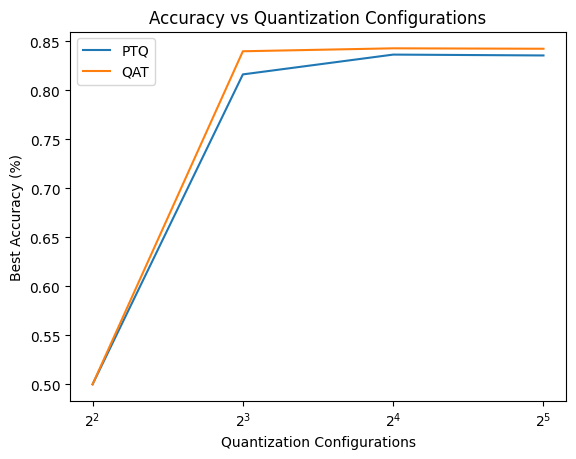

In [47]:
import matplotlib.pyplot as plt

ws = [w for w, fw in widths]

fig = plt.figure()
plt.plot(ws, ptq_results, label="PTQ")
plt.plot(ws, qat_results, label="QAT")
plt.xticks(ws)
plt.xscale('log', base=2)

plt.xlabel("Quantization Configurations")
plt.ylabel("Best Accuracy (%)")
plt.title("Accuracy vs Quantization Configurations")
plt.legend()
plt.savefig("tut3_accuracy_vs_quantization_configs.png")
plt.show()

In [16]:
# best config
from chop import MaseGraph, passes
from chop.tools import get_trainer
from pathlib import Path

mg = MaseGraph.from_checkpoint(f"{Path.home()}/tutorial_2_lora")
mg, _ = passes.quantize_transform_pass(
    mg,
    pass_args=get_config((16,8)),
)

trainer = get_trainer(
    model=mg.model,
    tokenized_dataset=dataset,
    tokenizer=tokenizer,
    evaluate_metric="accuracy",
    use_mps_device=True,
)

trainer.train()
mg.export(f"{Path.home()}/tutorial_3_best_fixpoint16_qat")
eval_results = trainer.evaluate()

WARNING  Node finfo not found in loaded metadata.
WARNING  Node getattr_2 not found in loaded metadata.
/opt/anaconda3/envs/mase/lib/python3.11/site-packages/transformers/training_args.py:2243: UserWarning: `use_mps_device` is deprecated and will be removed in version 5.0 of 🤗 Transformers. `mps` device will be used by default if available similar to the way `cuda` device is used.Therefore, no action from user is required. 
  warnings.warn(
/Users/harryni/Documents/EIE4/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
500,0.394800
1000,0.380600
1500,0.393800
2000,0.377500
2500,0.382800
3000,0.382700


INFO     Exporting MaseGraph to /Users/harryni/tutorial_3_best_fixpoint16_qat.pt, /Users/harryni/tutorial_3_best_fixpoint16_qat.mz
INFO     Exporting GraphModule to /Users/harryni/tutorial_3_best_fixpoint16_qat.pt
INFO     Exporting MaseMetadata to /Users/harryni/tutorial_3_best_fixpoint16_qat.mz


In [17]:
print(f"Evaluation accuracy: {eval_results['eval_accuracy']}")

Evaluation accuracy: 0.8428
